<a href="https://colab.research.google.com/github/loicPf/test_ia/blob/main/TP_Biais_Stagiaires_Titanic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TP Colab — Identifier et atténuer les biais de données
## Version Stagiaires (exercices)

**Dataset open-source :** Titanic (OpenML)

### Objectifs
1) Explorer les distributions et repérer un biais potentiel
2) Créer un dataset **biaisé** (biais de sélection / échantillonnage)
3) Mesurer l’effet via des **métriques par groupe**
4) Atténuer le biais via **équilibrage**
5) Comparer **avant / après**

> Target : **survived** (0/1). Groupes : **sex**, **pclass**.


In [1]:
!pip -q install -U pandas scikit-learn matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 2.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 1.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 30.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 36.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 29.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.0 which is incompatible.
bqplot 0.12.45 requires pandas<3.0.0,>=1.0.0, but you have pandas 3.0.0 which is incompatible.
db-dtypes 1.5.0 requires pandas<3.0.0,>=1.5.3, but you have pandas 3.0.0 which is incompatible.
gradio 5.50.0 requires pandas<3.0,>=1.0, but you have pandas 3.0.0 which is incompatible.


In [2]:
# Cellule 1 — Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix
from sklearn.impute import SimpleImputer

pd.set_option('display.max_columns', 200)
np.random.seed(42)


In [3]:
# Cellule 2 — Visualisation
def plot_bar(series, title):
    counts = series.value_counts(dropna=False)
    ax = counts.plot(kind='bar')
    ax.set_title(title)
    ax.set_xlabel(series.name)
    ax.set_ylabel('count')
    plt.xticks(rotation=30, ha='right')
    plt.tight_layout()
    plt.show()


In [4]:
# Cellule 3 — Charger Titanic (OpenML)
titanic = fetch_openml('titanic', version=1, as_frame=True)
df = titanic.frame.copy()
print('Raw shape:', df.shape)
df.head()


Raw shape: (1309, 14)


,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest
0,1,1,"Allen, Miss. Elisabeth Walton",female,29.0000,0,0,24160,211.3375,B5,S,2,NaN,"St Louis, MO"
1,1,1,"Allison, Master. Hudson Trevor",male,0.9167,1,2,113781,151.5500,C22 C26,S,11,NaN,"Montreal, PQ / Chesterville, ON"
2,1,0,"Allison, Miss. Helen Loraine",female,2.0000,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"
3,1,0,"Allison, Mr. Hudson Joshua Creighton",male,30.0000,1,2,113781,151.5500,C22 C26,S,NaN,135.0,"Montreal, PQ / Chesterville, ON"
4,1,0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.0000,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"


In [5]:
# Cellule 4 — Préparation simple
keep_cols = ['survived', 'sex', 'age', 'pclass', 'fare', 'embarked']
df = df[keep_cols].copy()
df['pclass'] = df['pclass'].astype(str)
print('After select:', df.shape)
df.head()


After select: (1309, 6)


,survived,sex,age,pclass,fare,embarked
0,1,female,29.0000,1,211.3375,S
1,1,male,0.9167,1,151.5500,S
2,0,female,2.0000,1,151.5500,S
3,0,male,30.0000,1,151.5500,S
4,0,female,25.0000,1,151.5500,S


## Exercice 1 — Explorer les distributions
Visualise `sex`, `pclass`, `survived`.

Questions :
- Quelles variables te semblent “sensibles” pour analyser un biais ?
- La cible est-elle déséquilibrée ?


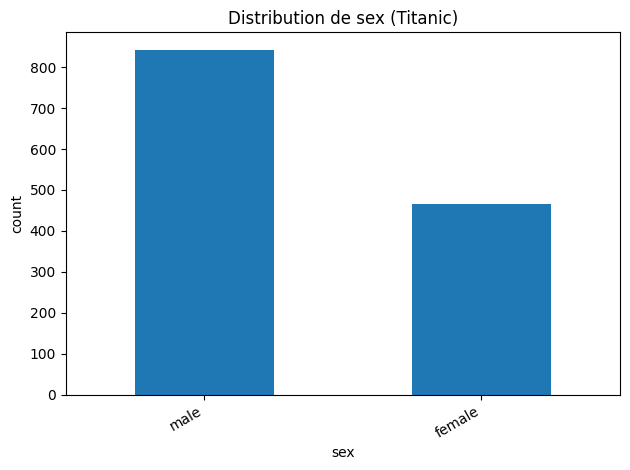

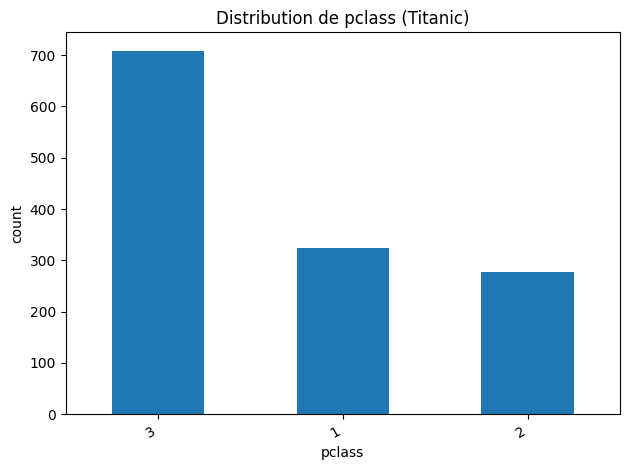

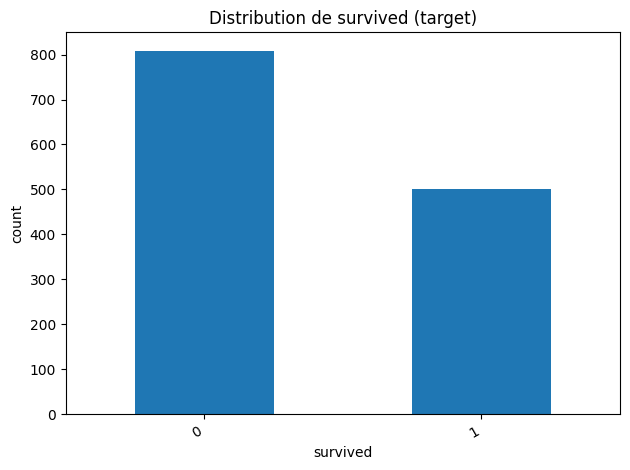

In [6]:
# Cellule 5 — Distributions
plot_bar(df['sex'], 'Distribution de sex (Titanic)')
plot_bar(df['pclass'], 'Distribution de pclass (Titanic)')
plot_bar(df['survived'], 'Distribution de survived (target)')


### Mini-tâche (coding)
Affiche la **proportion** (en %) de `male` et `female`.


In [8]:
# Cellule 6 — TODO
# TODO: utilise value_counts(normalize=True)
sex_ratio = (df['sex'].value_counts(normalize=True) * 100).round(2)
sex_ratio


sex
male      64.4
female    35.6
Name: proportion, dtype: float64

---
## Exercice 2 — Créer un dataset biaisé
On simule un **biais de sélection** :
- **80%** de `male`
- **70%** de `pclass='3'`


In [9]:
# Cellule 7 — Fonction dataset biaisé
def make_biased_dataset(df, n_total=900, male_ratio=0.80, pclass3_ratio=0.70, random_state=42):
    # 1) Biais sur sex
    df_m = df[df['sex'] == 'male']
    df_f = df[df['sex'] == 'female']
    n_m = int(n_total * male_ratio)
    n_f = n_total - n_m
    part_sex = pd.concat([
        df_m.sample(n=min(n_m, len(df_m)), random_state=random_state),
        df_f.sample(n=min(n_f, len(df_f)), random_state=random_state),
    ], axis=0)

    # 2) Biais sur pclass
    df_3 = part_sex[part_sex['pclass'] == '3']
    df_not3 = part_sex[part_sex['pclass'] != '3']
    n_3 = int(n_total * pclass3_ratio)
    n_not3 = n_total - n_3
    out = pd.concat([
        df_3.sample(n=min(n_3, len(df_3)), random_state=random_state),
        df_not3.sample(n=min(n_not3, len(df_not3)), random_state=random_state),
    ], axis=0).sample(frac=1, random_state=random_state).reset_index(drop=True)
    return out


In [12]:
# Cellule 8 — TODO
n_total = 900
# TODO: df_ref = échantillon aléatoire ; df_biased = dataset biaisé
df_ref = df.sample(n=n_total, random_state=42).reset_index(drop=True)
df_biased = make_biased_dataset(df, n_total=n_total, random_state=42)

print('df_ref:', df_ref.shape, '| df_biased:', df_biased.shape)
display(df_ref['sex'].value_counts(normalize=True))
display(df_biased['sex'].value_counts(normalize=True))
display(df_ref['pclass'].value_counts(normalize=True))
display(df_biased['pclass'].value_counts(normalize=True))


df_ref: (900, 6) | df_biased: (774, 6)


sex
male      0.652222
female    0.347778
Name: proportion, dtype: float64

sex
male      0.81137
female    0.18863
Name: proportion, dtype: float64

pclass
3    0.523333
1    0.250000
2    0.226667
Name: proportion, dtype: float64

pclass
3    0.651163
1    0.186047
2    0.162791
Name: proportion, dtype: float64

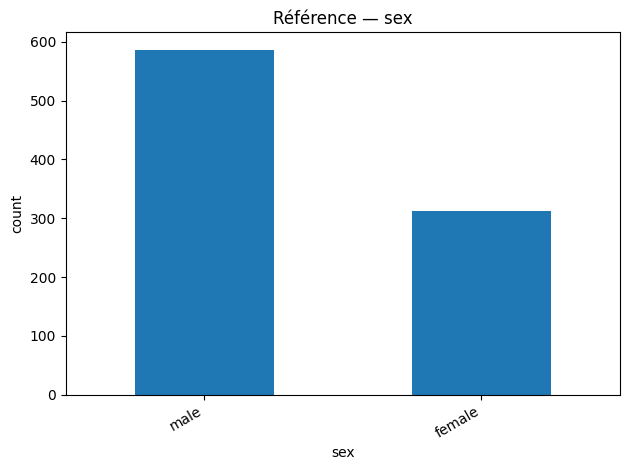

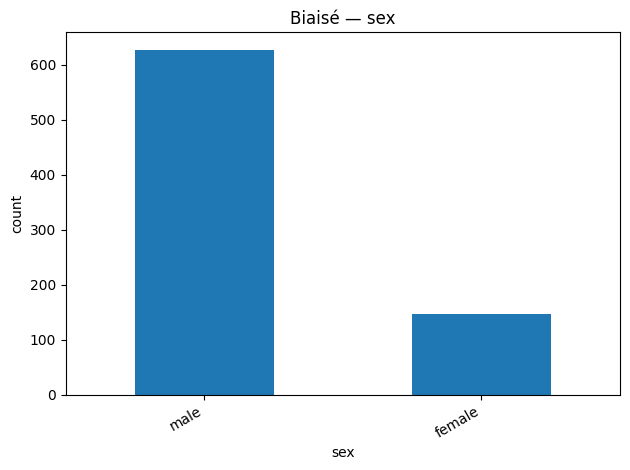

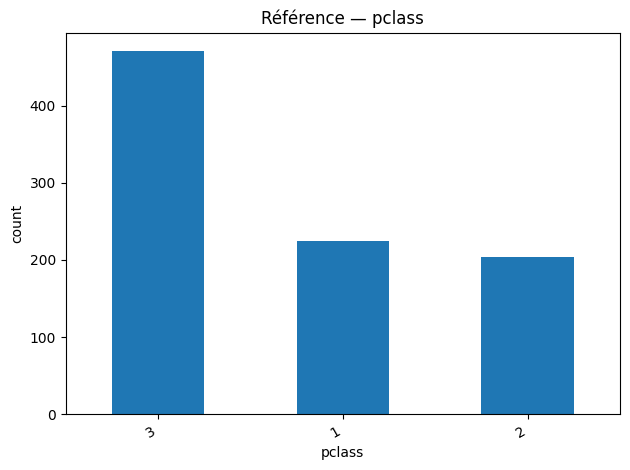

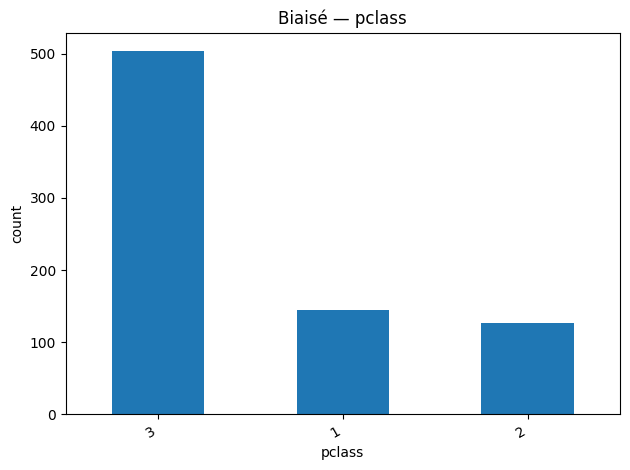

In [13]:
# Cellule 9 — Visualisation des distributions
plot_bar(df_ref['sex'], 'Référence — sex')
plot_bar(df_biased['sex'], 'Biaisé — sex')
plot_bar(df_ref['pclass'], 'Référence — pclass')
plot_bar(df_biased['pclass'], 'Biaisé — pclass')


---
## Exercice 3 — Mesurer le biais dans les données
Calcule le **taux de `survived=1`** par groupe (`sex`, `pclass`) sur `df_ref` et `df_biased`.


In [14]:
# Cellule 10 — TODO
def rate_by_group(data, group_col, target_col='survived'):
    s = pd.to_numeric(data[target_col], errors='coerce')
    return s.groupby(data[group_col]).mean().sort_values(ascending=False)

print('Taux survived=1 par sex (référence):')
display(rate_by_group(df_ref, 'sex'))

print('Taux survived=1 par sex (biaisé):')
display(rate_by_group(df_biased, 'sex'))

print('Taux survived=1 par pclass (référence):')
display(rate_by_group(df_ref, 'pclass'))

print('Taux survived=1 par pclass (biaisé):')
display(rate_by_group(df_biased, 'pclass'))


Taux survived=1 par sex (référence):


sex
female    0.750799
male      0.187394
Name: survived, dtype: float64

Taux survived=1 par sex (biaisé):


sex
female    0.705479
male      0.179936
Name: survived, dtype: float64

Taux survived=1 par pclass (référence):


pclass
1    0.617778
2    0.416667
3    0.256900
Name: survived, dtype: float64

Taux survived=1 par pclass (biaisé):


pclass
1    0.513889
2    0.317460
3    0.202381
Name: survived, dtype: float64

---
## Exercice 4 — Modèle + métriques par groupe
On entraîne une **Logistic Regression** et on calcule les métriques **par groupe**.
À surveiller : `pred_positive_rate`, `recall_tpr`, `fpr`.


In [15]:
# Cellule 11 — Rapport par groupe + gaps
def group_report(y_true, y_pred, group, positive_label=1):
    dfm = pd.DataFrame({'y_true': y_true, 'y_pred': y_pred, 'group': group})
    rows = []
    for g, sub in dfm.groupby('group'):
        yt = sub['y_true'].values
        yp = sub['y_pred'].values
        acc = accuracy_score(yt, yp)
        prec = precision_score(yt, yp, zero_division=0)
        rec = recall_score(yt, yp, zero_division=0)  # TPR
        tn, fp, fn, tp = confusion_matrix(yt, yp, labels=[0,1]).ravel()
        fpr = fp / (fp + tn) if (fp + tn) else np.nan
        pred_pos_rate = (yp == positive_label).mean()
        rows.append({'group': g, 'n': len(sub), 'accuracy': acc, 'precision': prec,
                     'recall_tpr': rec, 'fpr': fpr, 'pred_positive_rate': pred_pos_rate})
    return pd.DataFrame(rows).sort_values('group').reset_index(drop=True)

def fairness_gaps(report_df):
    if report_df.shape[0] != 2:
        return {}
    a = report_df.iloc[0]
    b = report_df.iloc[1]
    return {
        'demographic_parity_diff': float(b['pred_positive_rate'] - a['pred_positive_rate']),
        'equal_opportunity_diff_tpr': float(b['recall_tpr'] - a['recall_tpr']),
        'fpr_diff': float(b['fpr'] - a['fpr']),
        'accuracy_diff': float(b['accuracy'] - a['accuracy'])
    }


In [16]:
# Cellule 12 — Pipeline ML (imputation + encodage)
TARGET = 'survived'
FEATURES = [c for c in df.columns if c != TARGET]

def make_pipeline(X: pd.DataFrame):
    cat_cols = X.select_dtypes(include=['object','category']).columns.tolist()
    num_cols = X.select_dtypes(exclude=['object','category']).columns.tolist()

    num_pipe = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ])
    cat_pipe = Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore'))
    ])

    preproc = ColumnTransformer([
        ('num', num_pipe, num_cols),
        ('cat', cat_pipe, cat_cols)
    ])
    clf = LogisticRegression(max_iter=500)
    return Pipeline([('prep', preproc), ('clf', clf)])

def train_eval(data: pd.DataFrame, group_col='sex', title=''):
    X = data[FEATURES]
    y = data[TARGET].astype(int)
    g = data[group_col].astype(str)

    X_train, X_test, y_train, y_test, g_train, g_test = train_test_split(
        X, y, g, test_size=0.25, random_state=42, stratify=y
    )
    pipe = make_pipeline(X_train)
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)

    overall = {'title': title,
               'accuracy': accuracy_score(y_test, y_pred),
               'precision': precision_score(y_test, y_pred, zero_division=0),
               'recall': recall_score(y_test, y_pred, zero_division=0)}
    rep = group_report(y_test, y_pred, g_test)
    gaps = fairness_gaps(rep)
    return overall, rep, gaps


In [18]:
# Cellule 13 — TODO
# TODO: évaluer sur df_ref et df_biased (group_col='sex') avec train_eval
overall_ref, rep_ref, gaps_ref = train_eval(df_ref, group_col='sex', title='Référence')
overall_b, rep_b, gaps_b = train_eval(df_biased, group_col='sex', title='Biaisé')

print('=== Référence (sex) ===')
display(rep_ref)
print('Gaps:', gaps_ref)

print('\n=== Biaisé (sex) ===')
display(rep_b)
print('Gaps:', gaps_b)


/tmp/ipython-input-921045413.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X.select_dtypes(include=['object','category']).columns.tolist()
/tmp/ipython-input-921045413.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-se

=== Référence (sex) ===


,group,n,accuracy,precision,recall_tpr,fpr,pred_positive_rate
0,female,76,0.736842,0.733333,1.000000,0.952381,0.986842
1,male,149,0.791946,0.500000,0.032258,0.008475,0.013423


Gaps: {'demographic_parity_diff': -0.9734192864712116, 'equal_opportunity_diff_tpr': -0.967741935483871, 'fpr_diff': -0.9439063761097659, 'accuracy_diff': 0.05510420346167433}

=== Biaisé (sex) ===


,group,n,accuracy,precision,recall_tpr,fpr,pred_positive_rate
0,female,35,0.771429,0.757576,1.000000,0.800000,0.942857
1,male,159,0.823899,0.600000,0.103448,0.015385,0.031447


Gaps: {'demographic_parity_diff': -0.9114106019766397, 'equal_opportunity_diff_tpr': -0.896551724137931, 'fpr_diff': -0.7846153846153847, 'accuracy_diff': 0.052470799640610966}


### Mini-tâche (coding)
Refais l’évaluation avec `group_col='pclass'`. Que constates-tu ?


---
## Exercice 5 — Atténuation : équilibrage
On construit un dataset équilibré sur **sex × survived**.
Option : **sex × pclass × survived**.


df_balanced: (900, 6)


survived,0,1
sex,,
female,225,225
male,225,225


survived,0,1
sex,,
female,0.5,0.5
male,0.5,0.5


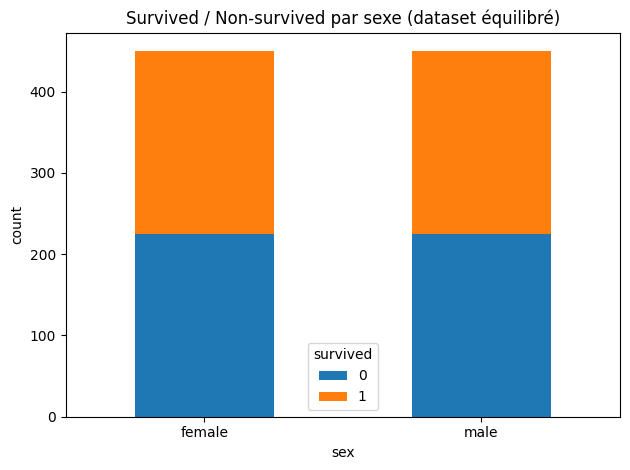

In [19]:
# --- 1) Fonction d'équilibrage sex puis survived dans chaque sex ---
def make_balanced_sex_then_survival(df_in, n_total=900, random_state=42, replace=True):
    """
    Construit un dataset équilibré :
    - 50% male / 50% female
    - dans chaque sexe : 50% survived=1 / 50% survived=0
    """
    rng = np.random.RandomState(random_state)

    # Sécuriser les types (important avec OpenML)
    df_work = df_in.copy()
    df_work["sex"] = df_work["sex"].astype(str).str.lower()
    df_work["survived"] = pd.to_numeric(df_work["survived"], errors="coerce").astype("Int64")

    # On ne garde que les lignes avec survived connu (0/1)
    df_work = df_work[df_work["survived"].isin([0, 1])].copy()

    sexes = ["female", "male"]
    # si une valeur est absente, on adapte
    present_sexes = [s for s in sexes if (df_work["sex"] == s).any()]
    if len(present_sexes) < 2:
        raise ValueError(f"Impossible: un seul sexe présent dans les données: {present_sexes}")

    # 50/50 sexes
    n_per_sex = n_total // 2
    # 50/50 survived à l'intérieur de chaque sexe
    n_per_class = n_per_sex // 2  # par (sex, survived)

    parts = []
    for s in sexes:
        for y in [0, 1]:
            sub = df_work[(df_work["sex"] == s) & (df_work["survived"] == y)]
            if len(sub) == 0:
                raise ValueError(f"Aucune ligne pour (sex={s}, survived={y}) -> impossible d'équilibrer.")
            parts.append(sub.sample(n=n_per_class, replace=replace, random_state=random_state))

    df_balanced = (
        pd.concat(parts, axis=0)
          .sample(frac=1, random_state=random_state)
          .reset_index(drop=True)
    )
    return df_balanced


# --- 2) Construire df_balanced avec l'équilibrage demandé ---
df_balanced = make_balanced_sex_then_survival(df_biased, n_total=900, random_state=42, replace=True)

print("df_balanced:", df_balanced.shape)

# --- 3) Vérifications : tableau sex x survived ---
ct_counts = pd.crosstab(df_balanced["sex"], df_balanced["survived"])
display(ct_counts)

ct_norm = pd.crosstab(df_balanced["sex"], df_balanced["survived"], normalize="index")
display(ct_norm)

# --- 4) Visualisation : barres empilées (sex vs survived) ---
ax = ct_counts.plot(kind="bar", stacked=True)
ax.set_title("Survived / Non-survived par sexe (dataset équilibré)")
ax.set_xlabel("sex")
ax.set_ylabel("count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


In [20]:
# Cellule 16 — TODO
# TODO: réentraîner sur df_balanced et comparer Biaisé vs Balanced avec la fonction train_eval
overall_bal, rep_bal, gaps_bal = train_eval(df_balanced, group_col='sex', title='Balanced')

print('=== Biaisé (sex) ===')
display(rep_b)
print('Gaps:', gaps_b)

print('\n=== Balanced (sex) ===')
display(rep_bal)
print('Gaps:', gaps_bal)


=== Biaisé (sex) ===


/tmp/ipython-input-921045413.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X.select_dtypes(include=['object','category']).columns.tolist()


,group,n,accuracy,precision,recall_tpr,fpr,pred_positive_rate
0,female,35,0.771429,0.757576,1.000000,0.800000,0.942857
1,male,159,0.823899,0.600000,0.103448,0.015385,0.031447


Gaps: {'demographic_parity_diff': -0.9114106019766397, 'equal_opportunity_diff_tpr': -0.896551724137931, 'fpr_diff': -0.7846153846153847, 'accuracy_diff': 0.052470799640610966}

=== Balanced (sex) ===


,group,n,accuracy,precision,recall_tpr,fpr,pred_positive_rate
0,female,114,0.745614,0.829268,0.607143,0.120690,0.359649
1,male,111,0.648649,0.688889,0.553571,0.254545,0.405405


Gaps: {'demographic_parity_diff': 0.045756282598387876, 'equal_opportunity_diff_tpr': -0.05357142857142849, 'fpr_diff': 0.1338557993730407, 'accuracy_diff': -0.0969653864390706}


---
## Exercice 6
Écris 3 phrases :
1) Quel biais a été simulé ?
2) Quelle atténuation a été appliquée ?
3) Quelle métrique (gap) a le plus changé ?


In [21]:
# Cellule 17 — Tableau de synthèse (optionnel)
def summarize(overall, gaps, label):
    d = {'exp': label, 'accuracy': overall['accuracy'], 'precision': overall['precision'], 'recall': overall['recall']}
    for k, v in gaps.items():
        d[k] = v
    return d

summary_rows = []
try:
    summary_rows.append(summarize(overall_ref, gaps_ref, 'Référence'))
    summary_rows.append(summarize(overall_b, gaps_b, 'Biaisé'))
    summary_rows.append(summarize(overall_bal, gaps_bal, 'Balanced'))
except Exception as e:
    print('⚠️ Exécute d’abord les cellules de training (overall_*, gaps_*).')
    print('Erreur:', e)

pd.DataFrame(summary_rows)


,exp,accuracy,precision,recall,demographic_parity_diff,equal_opportunity_diff_tpr,fpr_diff,accuracy_diff
0,Référence,0.773333,0.727273,0.651163,-0.973419,-0.967742,-0.943906,0.055104
1,Biaisé,0.814433,0.736842,0.518519,-0.911411,-0.896552,-0.784615,0.052471
2,Balanced,0.697778,0.755814,0.580357,0.045756,-0.053571,0.133856,-0.096965
